In [157]:
import pandas as pd
import numpy as np
import psycopg
from dotenv import load_dotenv
import os
import time

## 1) Pobranie danych i zapisanie do bazy danych

In [ ]:
load_dotenv()
def make_connection():
    user = os.getenv("DBUSER")
    passwd = os.getenv("DBPASSWORD")
    host = os.getenv("DBHOST")
    dbname = os.getenv("DBNAME")

    try:
        return psycopg.connect(f"dbname={dbname} user={user} host={host} password={passwd}")
    except:
        return False

In [7]:
conn = make_connection()

if conn:
    print("Połączono!")
else:
    print("Nie udało się!")

Połączono!


In [12]:
conn.close()

## Pobieranie danych z API

### Wybrane waluty:
- korona czeska (CZK)
- dolar amerykański (USD)
- euro (EUR)
- forint (HUF)
- jen (JPY)
- hrywna (UAH)

In [2]:
import requests
import json
from io import StringIO

In [9]:
resp = requests.get(r"https://api.nbp.pl/api/exchangerates/tables/A/2026-04-09/2026-06-11", headers = {'Accept': 'application/json'})
try:
    assert resp.status_code == 200
except:
    print(resp.status_code)


In [41]:
codes = ['USD', 'EUR', 'HUF', 'JPY', 'UAH', 'CZK']
data = resp.json()

In [121]:
def filter_rates(data):
    filtered = []
    for row in data:
        
        row_dict = {}
        row_dict['date'] = row['effectiveDate']
        rates = row['rates']
        filtered_rates = [*filter(lambda x: x['code'] in codes, rates)]
    
        for rate in filtered_rates:
            row_dict[f"{rate['code']}"] = rate['mid']
        
        filtered.append(row_dict)

    return filtered

In [122]:
filtered = filter_rates(data)

In [123]:
data_buff = StringIO(json.dumps(filtered))

In [124]:
df = pd.read_json(data_buff, orient = "records")
df['date'] = pd.to_datetime(df['date'])

In [125]:
df.set_index("date", inplace = True)

In [126]:
df

,USD,EUR,HUF,UAH,JPY,CZK
date,,,,,,
2026-04-09,3.6506,4.2610,0.011269,0.0840,0.022959,0.1746
2026-04-10,3.6396,4.2534,0.011287,0.0838,0.022845,0.1745
2026-04-13,3.6374,4.2507,0.011602,0.0837,0.022775,0.1744
2026-04-14,3.6015,4.2436,0.011681,0.0828,0.022642,0.1742
2026-04-15,3.5939,4.2370,0.011648,0.0826,0.022635,0.1740
2026-04-16,3.5983,4.2411,0.011629,0.0825,0.022633,0.1742
2026-04-17,3.5912,4.2355,0.011639,0.0818,0.022566,0.1742
2026-04-20,3.6005,4.2346,0.011678,0.0816,0.022647,0.1743
2026-04-21,3.5970,4.2320,0.011698,0.0815,0.022598,0.1742


In [127]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df_scaled = pd.DataFrame(sc.fit_transform(df), index = df.index, columns = df.columns)

In [128]:
from datetime import date, timedelta, datetime

datetime.strftime

<method 'strftime' of 'datetime.date' objects>

In [129]:
def make_date_chunks(start_date: date, end_date: date):
    """
    podział zakresu dat na okresy maksymalnie 90-dniowe (związane z limitami pobierania danych z API)
    """
    date_format = "%Y-%m-%d"
    
    dt = timedelta(days = 89)
    no_of_days = (end_date - start_date).days

    # ilość okresów o największej długości
    no_of_max_chunks = no_of_days // 90

    # ilość dat w ostatnim okresie
    last_chunk_size = no_of_days % 90

    # wynikiem będzie lista krotek z datą pierwszą i ostatnią danego okresu
    period_list = []

    # tworzenie zakresów
    curr_date = start_date
    for n in range(no_of_max_chunks):
        
        curr_date_str = curr_date.strftime(date_format)
        next_date_str = (curr_date + dt).strftime(date_format)
        period_tuple = (curr_date_str, next_date_str)
        
        period_list.append(period_tuple)
        curr_date = curr_date + timedelta(days = 90)

    # stworzenie ostatniego zakresu (o długości < od maksymalnej długości)
    if last_chunk_size:
        curr_date_str = curr_date.strftime(date_format)
        next_date_str = (curr_date + timedelta(days = last_chunk_size)).strftime(date_format)
        period_tuple = (curr_date_str, next_date_str)
        period_list.append(period_tuple)

    return period_list

In [130]:
make_date_chunks(d1,d2)

[('2022-06-12', '2022-09-09'),
 ('2022-09-10', '2022-12-08'),
 ('2022-12-09', '2023-03-08'),
 ('2023-03-09', '2023-06-06'),
 ('2023-06-07', '2023-06-12')]

In [250]:
def download_data(start_date_str, end_date_str):

    date_format = "%Y-%m-%d"

    start_date = datetime.strptime(start_date_str, date_format)
    end_date = datetime.strptime(end_date_str, date_format)

    periods = make_date_chunks(start_date, end_date)

    dates = pd.date_range(start_date, end_date)

    df = pd.DataFrame(columns = codes, index = dates)
    
    for period in periods:
        
        d1, d2 = period
        
        url = r"https://api.nbp.pl/api/exchangerates/tables/A/{}/{}".format(d1, d2)
        
        resp = requests.get(url, headers = {'Accept': 'application/json'})
        try:
            assert resp.status_code == 200
        except:
            print("Błąd pobierania!")
            print(resp.status_code)
            return

        data = resp.json()

        data = filter_rates(data)

        data_str = json.dumps(data)
        buff = StringIO(data_str)

        temp = pd.read_json(buff, orient = "records")
        temp.set_index("date", inplace = True)
        
        ix = temp.index.strftime(date_format)
        
        try:
            df.loc[ix] = temp.values
        except:
            pass
            
        print("poszło!")
        time.sleep(3)
    
    return df.astype("float")
        

        

In [260]:
def clean_data(data):

    return data.interpolate().bfill()

In [259]:
pd.DataFrame([np.nan, 1,2,3,4, np.nan]).interpolate()

,0
0,NaN
1,1.0
2,2.0
3,3.0
4,4.0
5,4.0


C:\Users\AdamD\AppData\Local\Temp\ipykernel_11544\2570552847.py:1: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['USD'].interpolate().plot()


<Axes: >

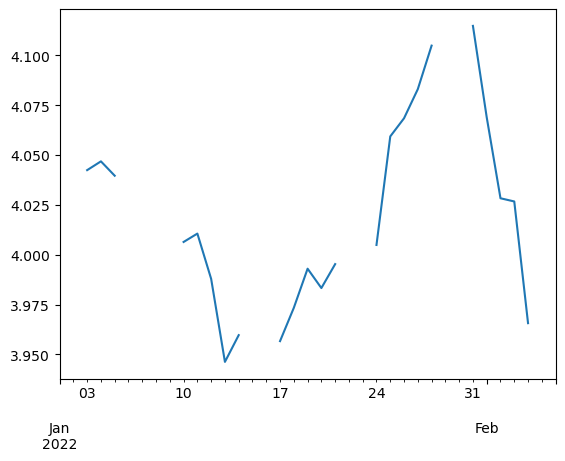

In [242]:
df['USD'].interpolate().plot()

In [179]:
date_range = pd.date_range("2022-01-01", "2023-09-06")
mask = date_range.isin(df.index)
df.loc[date_range[~mask], :] = np.nan

KeyError: "None of [DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-06', '2022-01-08',\n               '2022-01-09', '2022-01-15', '2022-01-16', '2022-01-22',\n               '2022-01-23', '2022-01-29',\n               ...\n               '2023-08-06', '2023-08-12', '2023-08-13', '2023-08-15',\n               '2023-08-19', '2023-08-20', '2023-08-26', '2023-08-27',\n               '2023-09-02', '2023-09-03'],\n              dtype='datetime64[ns]', length=190, freq=None)] are in the [index]"

In [185]:
date_range

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2023-08-28', '2023-08-29', '2023-08-30', '2023-08-31',
               '2023-09-01', '2023-09-02', '2023-09-03', '2023-09-04',
               '2023-09-05', '2023-09-06'],
              dtype='datetime64[ns]', length=614, freq='D')

In [181]:
test

,a
0,1
1,2
2,3


In [182]:
test.loc[4] = 4

In [183]:
test

,a
0,1
1,2
2,3
4,4
